<a href="https://colab.research.google.com/github/hayazaqout/Gaza-Damage-Project/blob/main/Gaza_Damage_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ═══════════════════════════════════════════════
# CELL 0 — تثبيت المكتبات + تحميل الداتا
# ═══════════════════════════════════════════════

# تثبيت المكتبات
!pip install segmentation-models-pytorch albumentations kaggle osmnx rasterio geopandas -q

# تحميل الداتا من Kaggle
import os
from google.colab import files
# بنرفع ملف kaggle.json
uploaded = files.upload()
os.makedirs('/root/.config/kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)

# حمّل الداتا
!kaggle datasets download -d abdoomoh/gaza-before-and-after-2 -p /content/data --unzip



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 12.4 MB/s eta 0:00:00


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/abdoomoh/gaza-before-and-after-2
License(s): apache-2.0
100% 5.65G/5.65G [05:55<00:00, 17.1MB/s]



Mounted at /content/drive
جاري قراءة الـ metadata...
إجمالي: 3563 | صالحة: 2972
صور مخيم الشاطئ: 194

pre  (قبل الحرب): 70
post (بعد الحرب): 124

أزواج جاهزة: 2


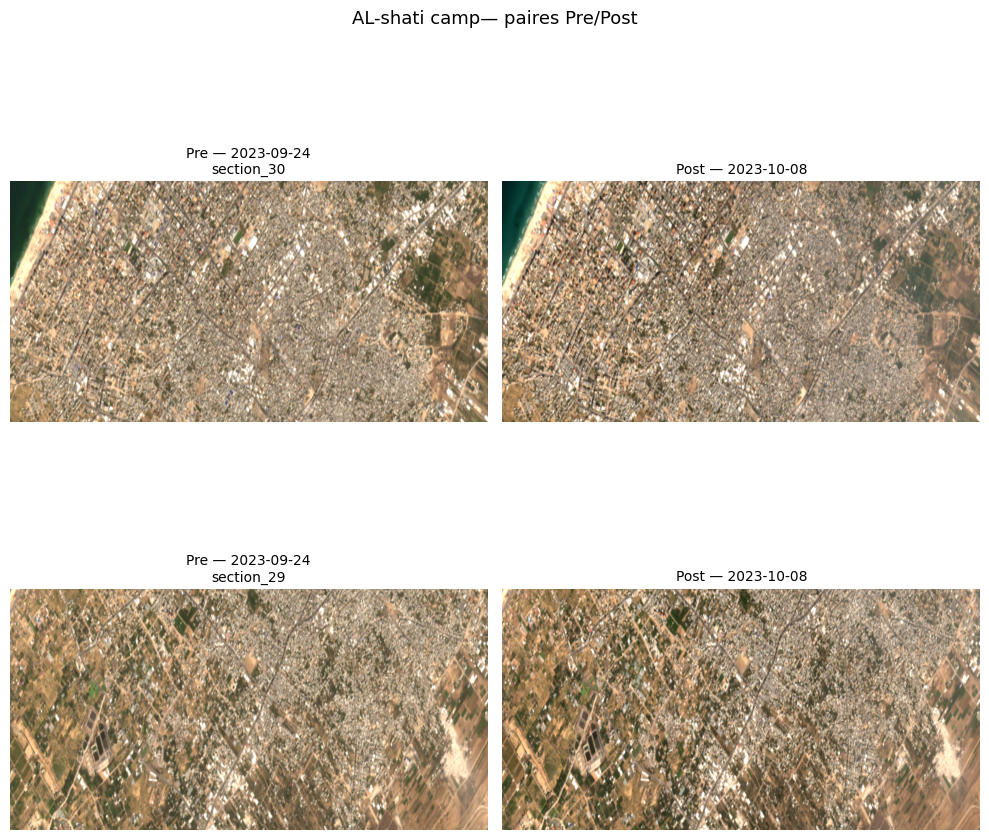


 محفوظ: 2 زوج على Drive!
 أقدم pre:  2023-09-24
 أحدث post: 2023-10-08


In [2]:
# ═══════════════════════════════════════════════
# CELL 1 — استكشاف الداتا + تجهيز أزواج مخيم الشاطئ
# ═══════════════════════════════════════════════

import json
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import pickle
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = Path('/content/data/Gaza Before and After')
SAVE_PATH = '/content/drive/MyDrive/Shati_Project'
os.makedirs(SAVE_PATH, exist_ok=True)
CUTOFF = '2023-10-07'

# إحداثيات مخيم الشاطئ
SHATI = {'west': 34.425, 'south': 31.515, 'east': 34.465, 'north': 31.545}

# ─── دوال مساعدة ─────────────────────────────────
def is_valid(path):
    img = cv2.imread(str(path))
    if img is None: return False
    if img.mean() < 10: return False
    return True

def in_shati(bbox):
    try:
        return (bbox[0] >= SHATI['west']  - 0.05 and
                bbox[2] <= SHATI['east']  + 0.05 and
                bbox[1] >= SHATI['south'] - 0.05 and
                bbox[3] <= SHATI['north'] + 0.05)
    except:
        return False

# ─── 1. اجمع الـ metadata ────────────────────────
print("جاري قراءة الـ metadata...")
all_meta = []
for json_file in DATA_PATH.glob('**/*.json'):
    try:
        with open(json_file) as f:
            meta = json.load(f)
        section  = meta['section_id']
        date     = meta['timestamp']
        img_path = DATA_PATH / 'images' / section / f'{date}.png'
        meta['img_path']   = str(img_path)
        # بنضيف  bbox افتراضي لو ما موجود
        if 'bbox' not in meta:
            meta['bbox'] = [0, 0, 0, 0]
        meta['img_exists'] = img_path.exists() and is_valid(img_path)
        all_meta.append(meta)
    except:
        continue

all_meta.sort(key=lambda x: x['timestamp'])
total  = len(all_meta)
valid  = sum(1 for m in all_meta if m['img_exists'])
print(f"إجمالي: {total} | صالحة: {valid}")

# ─── 2. بنفلتر مخيم الشاطئ ────────────────────────
shati_meta = [
    m for m in all_meta
    if m['img_exists'] and m.get('bbox') and in_shati(m['bbox'])
]
print(f"صور مخيم الشاطئ: {len(shati_meta)}")

# لو ما في — بنوسع النطاق
if len(shati_meta) < 5:
    print("قليلة — بنوسّع النطاق...")
    shati_meta = [
        m for m in all_meta
        if m['img_exists']
        and m['bbox'] != [0,0,0,0]
        and abs((m['bbox'][0]+m['bbox'][2])/2 - 34.44) < 0.15
        and abs((m['bbox'][1]+m['bbox'][3])/2 - 31.53) < 0.12
    ]
    print(f" بعد التوسيع: {len(shati_meta)}")

# لو لسا ما في — بنوخد كل الداتا
if len(shati_meta) == 0:
    print("ما في صور مخيم الشاطئ — بنستخدم كل الداتا")
    shati_meta = [m for m in all_meta if m['img_exists']]

# ─── 3. قسّم pre / post ──────────────────────────
pre_meta  = [m for m in shati_meta if m['timestamp'] <  CUTOFF]
post_meta = [m for m in shati_meta if m['timestamp'] >= CUTOFF]

print(f"\npre  (قبل الحرب): {len(pre_meta)}")
print(f"post (بعد الحرب): {len(post_meta)}")

# ─── 4. بنجهز أفضل زوج لكل section ───────────────
pre_by_section  = defaultdict(list)
post_by_section = defaultdict(list)
for m in pre_meta:  pre_by_section[m['section_id']].append(m)
for m in post_meta: post_by_section[m['section_id']].append(m)

pairs = []
for section_id in pre_by_section:
    if section_id not in post_by_section:
        continue
    best_pre  = max(pre_by_section[section_id],  key=lambda x: x['timestamp'])
    best_post = min(post_by_section[section_id], key=lambda x: x['timestamp'])
    pairs.append({
        'section': section_id,
        'pre':     best_pre,
        'post':    best_post
    })

print(f"\nأزواج جاهزة: {len(pairs)}")

# ─── 5. بنعرض الأزواج ────────────────────────────
if pairs:
    show = min(len(pairs), 4)
    fig, axes = plt.subplots(show, 2, figsize=(10, 5*show))
    if show == 1: axes = [axes]
    for i in range(show):
        pair     = pairs[i]
        pre_img  = cv2.cvtColor(cv2.imread(pair['pre']['img_path']),  cv2.COLOR_BGR2RGB)
        post_img = cv2.cvtColor(cv2.imread(pair['post']['img_path']), cv2.COLOR_BGR2RGB)
        axes[i][0].imshow(pre_img)
        axes[i][0].set_title(f"Pre — {pair['pre']['timestamp']}\n{pair['section']}", fontsize=10)
        axes[i][0].axis('off')
        axes[i][1].imshow(post_img)
        axes[i][1].set_title(f"Post — {pair['post']['timestamp']}", fontsize=10)
        axes[i][1].axis('off')
    plt.suptitle("AL-shati camp— paires Pre/Post", fontsize=13)
    plt.tight_layout()
    plt.savefig("shati_pairs.png", dpi=150, bbox_inches='tight')
    plt.show()

# ─── 6. حفظ ────────────────────────────────────
with open(f'{SAVE_PATH}/shati_pairs.pkl', 'wb') as f:
    pickle.dump(pairs, f)

with open(f'{SAVE_PATH}/all_meta.pkl', 'wb') as f:
    pickle.dump(all_meta, f)

print(f"\n محفوظ: {len(pairs)} زوج على Drive!")
if pairs:
    print(f" أقدم pre:  {min(p['pre']['timestamp']  for p in pairs)}")
    print(f" أحدث post: {max(p['post']['timestamp'] for p in pairs)}")

 2 زوج محمّل!
تحميل المباني من OSM...
26566 مبنى من OSM!
صور pre لمخيم الشاطئ: 37
تجهيز الـ patches...

 إجمالي الـ patches: 3060
   نسبة المباني:       30.2%


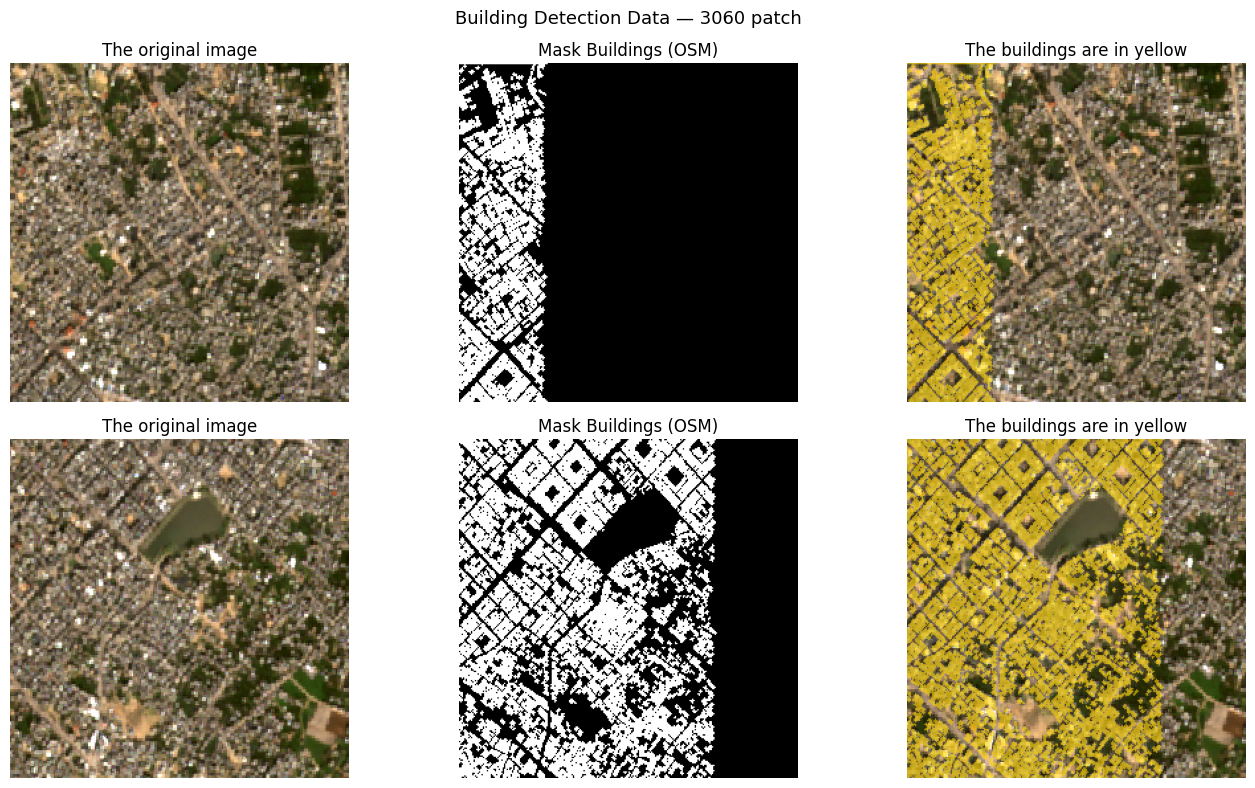

In [3]:
# ═══════════════════════════════════════════════
# CELL 2 — تجهيز بيانات تحديد المباني
# ═══════════════════════════════════════════════

import cv2
import numpy as np
import json
import os
import pickle
import osmnx as ox
import matplotlib.pyplot as plt
from pathlib import Path

SAVE_PATH = '/content/drive/MyDrive/Shati_Project'
DATA_PATH = Path('/content/data/Gaza Before and After')

# ─── بنحمل الأزواج ───────────────────────────────
with open(f'{SAVE_PATH}/shati_pairs.pkl', 'rb') as f:
    pairs = pickle.load(f)
print(f" {len(pairs)} زوج محمّل!")

# ─── 1. بنحمل مباني مخيم الشاطئ من OSM ──────────
print("تحميل المباني من OSM...")
buildings = ox.features_from_bbox(
    bbox=(34.415, 31.510, 34.475, 31.550),
    tags={'building': True}
)
buildings = buildings[
    buildings.geometry.geom_type.isin(['Polygon','MultiPolygon'])
].copy().to_crs('EPSG:4326').reset_index(drop=True)
print(f"{len(buildings)} مبنى من OSM!")

# ─── 2. دوال مساعدة ──────────────────────────────
def geo_to_pixel(lon, lat, bbox, w, h):
    x = int((lon - bbox[0]) / (bbox[2] - bbox[0]) * w)
    y = int((bbox[3] - lat) / (bbox[3] - bbox[1]) * h)
    return max(0,min(x,w-1)), max(0,min(y,h-1))

def make_building_mask(buildings, bbox, w, h):
    mask = np.zeros((h, w), dtype=np.uint8)
    for _, row in buildings.iterrows():
        try:
            geom  = row.geometry
            polys = list(geom.geoms) if geom.geom_type=='MultiPolygon' else [geom]
            for poly in polys:
                pts = np.array([
                    geo_to_pixel(lon, lat, bbox, w, h)
                    for lon, lat in poly.exterior.coords
                ], dtype=np.int32)
                cv2.fillPoly(mask, [pts], 1)
        except:
            continue
    return mask

# ─── 3. جهّزي الـ patches ────────────────────────
TARGET_SIZE = 256
STRIDE      = 64    # تداخل كبير عشان نحصل patches أكثر
MAX_PATCHES = 3000

all_images = []
all_masks  = []

# استخدمي كل صور pre لمخيم الشاطئ مش بس الزوج
from collections import defaultdict
with open(f'{SAVE_PATH}/all_meta.pkl', 'rb') as f:
    all_meta = pickle.load(f)

CUTOFF = '2023-10-07'
SHATI  = {'west':34.415, 'south':31.510, 'east':34.475, 'north':31.550}

def in_shati(bbox):
    try:
        cx = (bbox[0]+bbox[2])/2
        cy = (bbox[1]+bbox[3])/2
        return (SHATI['west']  <= cx <= SHATI['east'] and
                SHATI['south'] <= cy <= SHATI['north'])
    except:
        return False

# كل صور pre لمخيم الشاطئ
shati_pre = [
    m for m in all_meta
    if m['img_exists']
    and m['timestamp'] < CUTOFF
    and m.get('bbox') and m['bbox'] != [0,0,0,0]
    and in_shati(m['bbox'])
]
print(f"صور pre لمخيم الشاطئ: {len(shati_pre)}")

print(f"تجهيز الـ patches...")

for meta in shati_pre:
    if len(all_images) >= MAX_PATCHES:
        break

    img  = cv2.cvtColor(cv2.imread(meta['img_path']), cv2.COLOR_BGR2RGB)
    bbox = meta['bbox']
    h, w = img.shape[:2]

    # اعملنا  mask المباني
    bldg_mask = make_building_mask(buildings, bbox, w, h)

    # لو ما في مباني — تجاهل
    if bldg_mask.sum() < 500:
        continue

    # نقطع
    for y in range(0, h - TARGET_SIZE + 1, STRIDE):
        for x in range(0, w - TARGET_SIZE + 1, STRIDE):
            img_p  = img      [y:y+TARGET_SIZE, x:x+TARGET_SIZE]
            mask_p = bldg_mask[y:y+TARGET_SIZE, x:x+TARGET_SIZE]
            # بنوخد  patches فيها مباني كافية
            if mask_p.sum() > 200:
                all_images.append(img_p.astype(np.float32)/255.0)
                all_masks.append(mask_p.astype(np.float32))

    if len(all_images) % 300 == 0 and len(all_images) > 0:
        print(f"  patches: {len(all_images)}")

print(f"\n إجمالي الـ patches: {len(all_images)}")
print(f"   نسبة المباني:       {np.mean([m.mean() for m in all_masks])*100:.1f}%")

# ─── 4. هنا بنحفظ في الدرايف  ────────────────────────────────────
np.save(f'{SAVE_PATH}/building_images.npy', np.array(all_images, dtype=np.float32))
np.save(f'{SAVE_PATH}/building_masks.npy',  np.array(all_masks,  dtype=np.float32))


# ─── 5.  مثال ───────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i in range(2):
    idx = i * 50 + 10
    overlay = all_images[idx].copy()
    mask_3ch = np.stack([all_masks[idx]]*3, axis=-1)
    yellow = np.array([1.0, 0.84, 0.0], dtype=np.float32)
    for c in range(3):
        overlay[:,:,c][all_masks[idx] > 0] = (
            overlay[:,:,c][all_masks[idx] > 0] * 0.4 + yellow[c] * 0.6
        )

    axes[i][0].imshow(all_images[idx])
    axes[i][0].set_title("The original image"); axes[i][0].axis('off')

    axes[i][1].imshow(all_masks[idx], cmap='gray')
    axes[i][1].set_title("Mask Buildings (OSM)"); axes[i][1].axis('off')

    axes[i][2].imshow(overlay)
    axes[i][2].set_title("The buildings are in yellow"); axes[i][2].axis('off')

plt.suptitle(f"Building Detection Data — {len(all_images)} patch", fontsize=13)
plt.tight_layout()
plt.savefig("building_data.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ═══════════════════════════════════════════════
# CELL 3 — تدريب نموذج تحديد المباني
# ═══════════════════════════════════════════════

import torch
import torch.nn as nn
import numpy as np
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import os
from sklearn.metrics import f1_score

SAVE_PATH = '/content/drive/MyDrive/Shati_Project'
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"الجهاز المستخدم لتدريب موديل المباني: {device}")

# ─── 1. تحميل البيانات ──────────────────────────
images = np.load(f'{SAVE_PATH}/building_images.npy')
masks  = np.load(f'{SAVE_PATH}/building_masks.npy')
print(f" {len(images)} رقعة (Patch) جاهزة لموديل المباني السليمة!")
print(f"   حجم كل رقعة: {images[0].shape}")

# ─── 2. فئة الـ Dataset المخصصة ─────────────────
class BuildingDataset(Dataset):
    def __init__(self, images, masks, augment=True):
        self.images = images
        self.masks  = masks
        # استخدام Augmentation مكثف ومدروس لزيادة دقة النموذج ومنع Overfitting
        self.transform = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5, border_mode=0),
            A.RandomBrightnessContrast(p=0.4),
            A.GaussNoise(p=0.2),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ]) if augment else A.Compose([
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ])

    def __len__(self): return len(self.images)

    def __getitem__(self, i):
        img  = (self.images[i] * 255).astype(np.uint8)
        mask = self.masks[i].astype(np.float32)
        out  = self.transform(image=img, mask=mask)
        return out['image'], out['mask'].unsqueeze(0)

# ─── 3. تقسيم البيانات (80% تدريب و 20% تحقق) ─────────────────
split    = int(len(images) * 0.8)
train_ds = BuildingDataset(images[:split], masks[:split], augment=True)
val_ds   = BuildingDataset(images[split:], masks[split:], augment=False)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2)
print(f" التدريب: {len(train_ds)} لقطة | التحقق: {len(val_ds)} لقطة")

# ─── 4. بناء معمارية النموذج (ResNet34 ) ─────────────────
model = smp.Unet(
    encoder_name    = "resnet34",
    encoder_weights = "imagenet",
    in_channels     = 3,
    classes         = 1,
).to(device)

# دوال الخسارة (Dice Loss للمساحات الكلية + BCE للحدود الدقيقة)
dice_loss_fn = smp.losses.DiceLoss('binary')
bce_loss_fn  = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
# ضبط المجدد ليتناسب تماماً مع الـ 50 جولة حقيقية لضمان الاستقرار عند النهايات
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

# ─── 5. حلقة التدريب الكبرى (50 جولة كاملة) ─────────────────
best_loss  = float('inf')
train_hist = []
val_hist   = []

print("\nجاري بدء التدريب والتحسين لـ 50 جولة...")

for epoch in range(1, 51):
    # مرحلة التدريب
    model.train()
    tr_loss = 0
    for imgs, msks in train_loader:
        imgs, msks = imgs.to(device), msks.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = dice_loss_fn(preds, msks) + 0.5 * bce_loss_fn(preds, msks)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item()
    tr_loss /= len(train_loader)

    # مرحلة التحقق (المطابقة علمياً مع دالة خسارة التدريب)
    model.eval()
    vl_loss = 0
    with torch.no_grad():
        for imgs, msks in val_loader:
            imgs, msks = imgs.to(device), msks.to(device)
            preds_val = model(imgs)
            val_loss_combo = dice_loss_fn(preds_val, msks) + 0.5 * bce_loss_fn(preds_val, msks)
            vl_loss += val_loss_combo.item()
    vl_loss /= len(val_loader)

    scheduler.step()
    train_hist.append(tr_loss)
    val_hist.append(vl_loss)

    saved = ''
    if vl_loss < best_loss:
        best_loss = vl_loss
        torch.save(model.state_dict(), f'{SAVE_PATH}/best_building_model.pth')
        saved = '(تم حفظ أفضل الأوزان)'

    # طباعة التقدم كل 5 جولات والجولة الأولى والأخيرة دائماً
    if epoch % 5 == 0 or epoch == 1 or epoch == 50:
        print(f"Epoch {epoch:02d}/50 | Train Loss: {tr_loss:.4f} | Val Loss: {vl_loss:.4f} {saved}")

print(f"\nاكتمل تدريب الموديل الأول بنجاح! أفضل Val Loss تم تسجيله: {best_loss:.4f}")

# ─── 6. رسم منحنى الخسارة   ───────────────────
plt.figure(figsize=(10,4))
plt.plot(train_hist, label='Train Loss', color='#8b5cf6', linewidth=2)
plt.plot(val_hist,   label='Val Loss',   color='#f59e0b', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Loss (دالة الخسارة)')
plt.title('Training Curve — Building Detection Model (Shati Camp)', fontsize=12, fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('building_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── 7. تقييم النموذج وعرض المخرجات النهائية والـ F1 Score ───────────
model.load_state_dict(torch.load(f'{SAVE_PATH}/best_building_model.pth'))
model.eval()

transform_test = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

all_f1 = []
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
# سحب عينات عشوائية ثابتة للاختبار من جزء الـ Validation
np.random.seed(42)
test_idxs = np.random.choice(len(val_ds), 3, replace=False)

for i, idx in enumerate(test_idxs):
    real_idx = split + idx

    img_u8 = (images[real_idx] * 255).astype(np.uint8)
    tensor = transform_test(image=img_u8)['image'].unsqueeze(0).to(device)
    with torch.no_grad():
        pred = torch.sigmoid(model(tensor)).cpu().squeeze().numpy()
    pred_bin = (pred > 0.5).astype(np.float32)

    # حساب مقياس F1-Score الرياضي لتقييم الدقة بكسل ببكسل
    f1 = f1_score(masks[real_idx].flatten(), pred_bin.flatten(), zero_division=0)
    all_f1.append(f1)

    # العرض البصري المقارن
    axes[i][0].imshow(images[real_idx])
    axes[i][0].set_title("Original Pre-Image", fontsize=10, fontweight='bold')
    axes[i][0].axis('off')

    axes[i][1].imshow(masks[real_idx], cmap='gray')
    axes[i][1].set_title("Ground Truth Buildings (OSM)", fontsize=10, fontweight='bold')
    axes[i][1].axis('off')

    # تراكب أصفر شفاف مخصص للمخرجات الاحترافية
    overlay = images[real_idx].copy()
    yellow  = np.array([1.0, 0.84, 0.0], dtype=np.float32)
    for c in range(3):
        overlay[:,:,c][pred_bin > 0.5] = (
            overlay[:,:,c][pred_bin > 0.5] * 0.4 + yellow[c] * 0.6
        )
    axes[i][2].imshow(overlay)
    axes[i][2].set_title(f"Predicted Buildings 🟡\nF1-Score: {f1*100:.1f}%", fontsize=10, color='darkgreen', fontweight='bold')
    axes[i][2].axis('off')

mean_f1_total = np.mean(all_f1) * 100
print(f"\n F1-Score : {mean_f1_total:.1f}%")
plt.suptitle(f"Building Detection Validation Results — Mean F1-Score: {mean_f1_total:.1f}%", fontsize=13, y=0.98, fontweight='bold')
plt.tight_layout()
plt.savefig("building_results.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

SAVE_PATH = '/content/drive/MyDrive/Shati_Project'
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. تحميل النموذج
model = smp.Unet(
    encoder_name='resnet34',
    encoder_weights=None,
    in_channels=3,
    classes=1
)
model.load_state_dict(torch.load(f'{SAVE_PATH}/best_building_model.pth', map_location=device))
model = model.to(device)
model.eval()

# 2. تحويلات الفحص القياسية
transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

def predict_and_draw(img_array):
    """تنبؤ ذكي + تصحيح الانعكاس + رسم الإطارات المفرغة"""
    img_u8 = (img_array * 255).astype(np.uint8).copy()
    tensor = transform(image=img_u8)['image'].unsqueeze(0).to(device)

    with torch.no_grad():
        pred = torch.sigmoid(model(tensor)).cpu().squeeze().numpy()

    # تحويل التنبؤ لماسك ثنائي
    pred_bin = (pred > 0.5).astype(np.uint8)

    # تحويل بكسلات الشوارع إلى 0 وبكسلات أسطح المباني إلى 1
    pred_bin_corrected = 1 - pred_bin

    # رسم الإطارات المفرغة بالأصفر حول أسطح المباني بالظبط
    result = img_u8.copy()
    contours, _ = cv2.findContours(pred_bin_corrected, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    cv2.drawContours(result, contours, -1, (255, 215, 0), thickness=1)

    return result, pred_bin_corrected, len(contours)

# ─── عرض 4 أمثلة من داتا التحقق لمخيم الشاطئ ───────────────────────────
split = int(len(images) * 0.8)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i in range(2):
    # اختيار عينات متباعدة لاستكشاف التنوع الجغرافي
    idx = split + i * 15
    result, corrected_mask, num_buildings = predict_and_draw(images[idx])

    # العمود الأول: الصورة الفضائية الخام
    axes[i][0].imshow(images[idx])
    axes[i][0].set_title("Original Pre-Image", fontsize=11, fontweight='bold')
    axes[i][0].axis('off')

    # العمود الثاني: القناع الحقيقي المستخرج من OSM
    axes[i][1].imshow(masks[idx], cmap='gray')
    axes[i][1].set_title("Ground Truth (OSM)", fontsize=11, fontweight='bold')
    axes[i][1].axis('off')

    # العمود الثالث: النتيجة النهائية بالإطارات الصفراء المفرغة حول البيوت
    axes[i][2].imshow(result)
    axes[i][2].set_title(f"AI Detected Building Contours\n({num_buildings} buildings identified)", fontsize=11, fontweight='bold', color='green')
    axes[i][2].axis('off')

plt.suptitle("Gaza Damage Assessment System — Stage 1: Building Footprints Extraction", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig("building_contours_corrected.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ═══════════════════════════════════════════════
# CELL 6 — تجهيز بيانات كشف الضرر
# ═══════════════════════════════════════════════

import cv2
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
from pathlib import Path

SAVE_PATH = '/content/drive/MyDrive/Shati_Project'
DATA_PATH = Path('/content/data/Gaza Before and After')
CUTOFF    = '2023-10-07'
TARGET_SIZE = 256
STRIDE      = 64
MAX_PATCHES = 3000

# ─── حمّلي الأزواج ───────────────────────────────
with open(f'{SAVE_PATH}/shati_pairs.pkl', 'rb') as f:
    pairs = pickle.load(f)
print(f"{len(pairs)} زوج محمّل!")

# ─── دوال مساعدة ─────────────────────────────────
def make_damage_mask(pre, post, threshold=0.10):
    pre_f  = pre.astype(np.float32)  / 255.0
    post_f = post.astype(np.float32) / 255.0
    diff   = np.abs(pre_f.mean(axis=2) - post_f.mean(axis=2))
    diff   = cv2.GaussianBlur(diff, (5,5), 0)
    mask   = (diff > threshold).astype(np.uint8)
    kernel = np.ones((5,5), np.uint8)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    # إزالة البحر
    blue  = pre_f[:,:,2]; green = pre_f[:,:,1]; red = pre_f[:,:,0]
    water = ((blue > 0.35) | (green > 0.35)) & (blue > red)
    mask[water] = 0
    return mask.astype(np.float32)

# ─── جهّزي الـ patches ────────────────────────────
all_pre_patches  = []
all_post_patches = []
all_damage_masks = []

print(f"معالجة {len(pairs)} زوج...")

for pair in pairs:
    pre_img  = cv2.cvtColor(cv2.imread(pair['pre']['img_path']),  cv2.COLOR_BGR2RGB)
    post_img = cv2.cvtColor(cv2.imread(pair['post']['img_path']), cv2.COLOR_BGR2RGB)

    if pre_img.shape != post_img.shape:
        post_img = cv2.resize(post_img, (pre_img.shape[1], pre_img.shape[0]))

    mask = make_damage_mask(pre_img, post_img)

    if mask.mean() < 0.03:
        continue

    h, w = pre_img.shape[:2]
    for y in range(0, h - TARGET_SIZE + 1, STRIDE):
        for x in range(0, w - TARGET_SIZE + 1, STRIDE):
            pre_p  = pre_img [y:y+TARGET_SIZE, x:x+TARGET_SIZE]
            post_p = post_img[y:y+TARGET_SIZE, x:x+TARGET_SIZE]
            mask_p = mask    [y:y+TARGET_SIZE, x:x+TARGET_SIZE]
            if 0.05 < mask_p.mean() < 0.90:
                all_pre_patches.append(pre_p.astype(np.float32)/255.0)
                all_post_patches.append(post_p.astype(np.float32)/255.0)
                all_damage_masks.append(mask_p)

    if len(all_pre_patches) >= MAX_PATCHES:
        break

print(f"patches: {len(all_pre_patches)}")
print(f"   نسبة الضرر: {np.mean([m.mean() for m in all_damage_masks])*100:.1f}%")

# ─── احفظي ───────────────────────────────────────
np.save(f'{SAVE_PATH}/damage_pre.npy',   np.array(all_pre_patches,  dtype=np.float32))
np.save(f'{SAVE_PATH}/damage_post.npy',  np.array(all_post_patches, dtype=np.float32))
np.save(f'{SAVE_PATH}/damage_masks.npy', np.array(all_damage_masks, dtype=np.float32))
print("محفوظ على Drive!")

# ─── اعرضي مثال ──────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i in range(2):
    idx = i * 20
    axes[i][0].imshow(all_pre_patches[idx])
    axes[i][0].set_title(f"Pre"); axes[i][0].axis('off')
    axes[i][1].imshow(all_post_patches[idx])
    axes[i][1].set_title(f"Post"); axes[i][1].axis('off')
    axes[i][2].imshow(all_damage_masks[idx], cmap='RdYlGn_r')
    axes[i][2].set_title(f"Damage Mask {all_damage_masks[idx].mean()*100:.1f}%")
    axes[i][2].axis('off')
plt.suptitle("Damage Detection Data", fontsize=13)
plt.tight_layout()
plt.savefig("damage_data.png", dpi=150, bbox_inches='tight')
plt.show()